In [1]:
import pandas as pd
import numpy as np
from textblob import TextBlob
import emoji
import re

In [2]:
df = pd.read_csv('../data/features/youtube_features.csv')

In [3]:
df['title_length'] = df['title'].apply(len)
df['uppercase_words'] = df['title'].apply(lambda x: sum(1 for word in x.split() if word.isupper()))

In [4]:
def has_number_or_emojis(text):
    has_number = bool(re.search(r"\d", text))
    has_emoji = any(char in emoji.EMOJI_DATA for char in text)
    return int(has_number or has_emoji)

In [5]:
df["contains_numbers_or_emojis"] = df["title"].apply(has_number_or_emojis)

In [6]:
df['sentiment_polarity'] = df['title'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['sentiment_subjectivity'] = df["title"].apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [7]:
df.head()
df['contains_numbers_or_emojis'].describe()

count    55886.000000
mean         0.575779
std          0.494229
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: contains_numbers_or_emojis, dtype: float64

Text(0.5, 1.0, 'Views vs Presence of Numbers/Emojis')

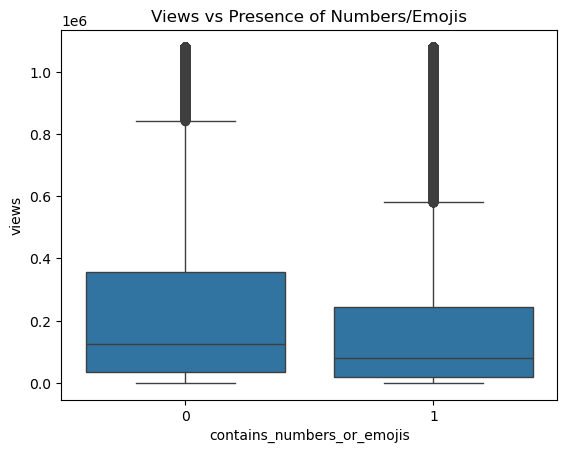

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='contains_numbers_or_emojis', y='views', data=df)
plt.title('Views vs Presence of Numbers/Emojis')






In [9]:
df.to_csv('../data/processed/youtube_features.csv', index=False)